In [11]:
# ==============================================================================
# ΜΗΝΑΣ 4: ΔΗΜΙΟΥΡΓΙΑ ΣΤΑΤΙΚΩΝ ΓΡΑΦΩΝ (GRAPH A & GRAPH B)
# ==============================================================================

import pandas as pd
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.api import VAR
from torch_geometric.utils import dense_to_sparse

warnings.filterwarnings('ignore')

# 1. Φόρτωση Κύριου Dataset (Yahoo Finance) - 10 νομίσματα
df_yahoo = pd.read_csv('crypto_log_returns_yahoo.csv', index_col='Date', parse_dates=True)
# Γεμίζουμε τα πιθανά NaNs με 0
df_yahoo = df_yahoo.fillna(0)

print(f"Δεδομένα Yahoo φορτώθηκαν: {df_yahoo.shape}")
num_nodes = df_yahoo.shape[1]

# --- Graph A: Correlation Graph (Pearson) ---
print("\n--- Υπολογισμός Graph A: Correlation Graph ---")
corr_matrix = df_yahoo.corr(method='pearson').values
# Thresholding: Κρατάμε ακμές μόνο με συσχέτιση > 0.4
adj_corr = np.where(np.abs(corr_matrix) > 0.4, corr_matrix, 0)
np.fill_diagonal(adj_corr, 0)
edge_index_corr, edge_weight_corr = dense_to_sparse(torch.tensor(adj_corr, dtype=torch.float32))

# --- Graph B: Volatility Spillover Graph (VAR) ---
print("--- Υπολογισμός Graph B: Spillover Graph (VAR) ---")
# Εκπαίδευση ενός γρήγορου VAR(1) για να βρούμε τα spillovers (πώς το coin A επηρεάζει το coin B)
var_model = VAR(df_yahoo)
var_results = var_model.fit(1)
spillover_matrix = var_results.coefs[0]
# Κρατάμε μόνο τις σημαντικές επιδράσεις (> 0.05)
adj_spill = np.where(np.abs(spillover_matrix) > 0.05, spillover_matrix, 0)
np.fill_diagonal(adj_spill, 0)
edge_index_spill, edge_weight_spill = dense_to_sparse(torch.tensor(adj_spill, dtype=torch.float32))

print(f"Correlation Edges: {edge_index_corr.shape[1]} | Spillover Edges: {edge_index_spill.shape[1]}")

Δεδομένα Yahoo φορτώθηκαν: (3046, 10)

--- Υπολογισμός Graph A: Correlation Graph ---
--- Υπολογισμός Graph B: Spillover Graph (VAR) ---
Correlation Edges: 84 | Spillover Edges: 24


In [12]:
# ==============================================================================
# ΠΡΟΕΤΟΙΜΑΣΙΑ 3D TENSORS ΓΙΑ ΤΑ ST-GNNs
# ==============================================================================
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Στόχος: Η Απόλυτη Απόδοση (Μεταβλητότητα) όλων των 10 νομισμάτων
volatility_data = np.abs(df_yahoo.values)

# Scaling 0-1
scaler = MinMaxScaler()
volatility_scaled = scaler.fit_transform(volatility_data)

# Δημιουργία X, y (Κοιτάμε 14 μέρες πίσω για να προβλέψουμε την επόμενη για ΟΛΑ τα coins)
SEQ_LENGTH = 14

def create_graph_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i : i + seq_len]     # Shape: [14, 10]
        y = data[i + seq_len]         # Shape: [10]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_graph_sequences(volatility_scaled, SEQ_LENGTH)

# Μετατροπή shape από [Batch, Time, Nodes] -> [Batch, Time, Nodes, 1 Feature]
X = np.expand_dims(X, axis=-1)

# Split 80/20
split_idx = int(len(X) * 0.8)
X_train, X_test = torch.FloatTensor(X[:split_idx]), torch.FloatTensor(X[split_idx:])
y_train, y_test = torch.FloatTensor(y[:split_idx]), torch.FloatTensor(y[split_idx:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)

print(f"X_train (GNN shape): {X_train.shape} -> [Batch, Time, Nodes, Features]")
print(f"y_train (GNN target): {y_train.shape} -> [Batch, Nodes]")

X_train (GNN shape): torch.Size([2425, 14, 10, 1]) -> [Batch, Time, Nodes, Features]
y_train (GNN target): torch.Size([2425, 10]) -> [Batch, Nodes]


In [13]:
# ==============================================================================
# ΑΡΧΙΤΕΚΤΟΝΙΚΕΣ GNN: GCN+LSTM και GAT+GRU
# ==============================================================================
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

# --- 1. GCN + LSTM (Το κλασικό T-GCN) ---
class TGCN_LSTM(torch.nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_dim=32, out_channels=1):
        super(TGCN_LSTM, self).__init__()
        self.num_nodes = num_nodes
        self.hidden_dim = hidden_dim

        self.gcn = GCNConv(in_channels, hidden_dim)
        self.lstm = torch.nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, seq_len, nodes, _ = x.shape

        spatial_seq = []
        for t in range(seq_len):
            x_t = x[:, t, :, :].reshape(-1, 1)
            h_t = F.relu(self.gcn(x_t, edge_index, edge_weight))
            h_t = h_t.reshape(batch_size, nodes, self.hidden_dim)
            spatial_seq.append(h_t)

        spatial_seq = torch.stack(spatial_seq, dim=1) # [Batch, Time, Nodes, Hidden]
        lstm_input = spatial_seq.permute(0, 2, 1, 3).reshape(batch_size * nodes, seq_len, self.hidden_dim)

        lstm_out, _ = self.lstm(lstm_input)
        out = self.fc(lstm_out[:, -1, :]) # Τελευταίο Time-Step
        out = out.reshape(batch_size, nodes)

        return F.softplus(out)

# --- 2. GAT + GRU ---
class TGAT_GRU(torch.nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_dim=32, out_channels=1):
        super(TGAT_GRU, self).__init__()
        self.num_nodes = num_nodes
        self.hidden_dim = hidden_dim

        # Το GAT βρίσκει δυναμικά βάρη ανάμεσα στους γείτονες
        self.gat = GATConv(in_channels, hidden_dim, heads=1)
        self.gru = torch.nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, seq_len, nodes, _ = x.shape

        spatial_seq = []
        for t in range(seq_len):
            x_t = x[:, t, :, :].reshape(-1, 1)
            # Το GAT δεν χρησιμοποιεί edge_weight, μαθαίνει τα δικά του βάρη
            h_t = F.relu(self.gat(x_t, edge_index))
            h_t = h_t.reshape(batch_size, nodes, self.hidden_dim)
            spatial_seq.append(h_t)

        spatial_seq = torch.stack(spatial_seq, dim=1)
        gru_input = spatial_seq.permute(0, 2, 1, 3).reshape(batch_size * nodes, seq_len, self.hidden_dim)

        gru_out, _ = self.gru(gru_input)
        out = self.fc(gru_out[:, -1, :])
        out = out.reshape(batch_size, nodes)

        return F.softplus(out)

print("GCN+LSTM και GAT+GRU δημιουργήθηκαν επιτυχώς!")

GCN+LSTM και GAT+GRU δημιουργήθηκαν επιτυχώς!


In [14]:
# ==============================================================================
# ΕΚΠΑΙΔΕΥΣΗ GNN MODELS ΚΑΙ ΕΞΑΓΩΓΗ METRICS
# ==============================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_gnn(model, name, edge_idx, edge_wt, epochs=50):
    print(f"\n--- Εκπαίδευση {name} ---")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for b_x, b_y in train_loader:
            optimizer.zero_grad()
            out = model(b_x, edge_idx, edge_wt)
            loss = criterion(out, b_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")
    return model

# 1. Εκπαίδευση
model_gcn_lstm = TGCN_LSTM(num_nodes)
model_gat_gru = TGAT_GRU(num_nodes)

train_gnn(model_gcn_lstm, "GCN+LSTM (Spillover Graph)", edge_index_spill, edge_weight_spill, epochs=40)
train_gnn(model_gat_gru, "GAT+GRU (Spillover Graph)", edge_index_spill, None, epochs=40)

# 2. Αξιολόγηση
def evaluate_gnn(model, name, edge_idx, edge_wt):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test, edge_idx, edge_wt).numpy()

    # Παίρνουμε μόνο το Node 0 (BTC) και κάνουμε Inverse Transform
    y_pred_btc = scaler.inverse_transform(y_pred)[:, 0] * 100
    y_true_btc = scaler.inverse_transform(y_test.numpy())[:, 0] * 100
    y_pred_btc = np.clip(y_pred_btc, 0.1, None)

    rmse = np.sqrt(mean_squared_error(y_true_btc, y_pred_btc))
    mae = mean_absolute_error(y_true_btc, y_pred_btc)
    qlike = np.mean(np.log(y_pred_btc**2) + (y_true_btc**2 / y_pred_btc**2))

    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

res_1 = evaluate_gnn(model_gcn_lstm, "GCN+LSTM", edge_index_spill, edge_weight_spill)
res_2 = evaluate_gnn(model_gat_gru, "GAT+GRU", edge_index_spill, None)

df_gnn = pd.DataFrame([res_1, res_2]).set_index('Model')
print("\n=== ST-GNN BENCHMARK (TEST SET - BTC) ===")
print(df_gnn.round(4))


--- Εκπαίδευση GCN+LSTM (Spillover Graph) ---
Epoch 10/40 | Loss: 0.0049
Epoch 20/40 | Loss: 0.0044
Epoch 30/40 | Loss: 0.0042
Epoch 40/40 | Loss: 0.0040

--- Εκπαίδευση GAT+GRU (Spillover Graph) ---
Epoch 10/40 | Loss: 0.0049
Epoch 20/40 | Loss: 0.0041
Epoch 30/40 | Loss: 0.0040
Epoch 40/40 | Loss: 0.0040

=== ST-GNN BENCHMARK (TEST SET - BTC) ===
            RMSE     MAE   QLIKE
Model                           
GCN+LSTM  1.6843  1.2577  2.8356
GAT+GRU   1.6752  1.2517  2.7983


In [15]:
# ==============================================================================
# ΜΗΝΑΣ 4 (ROBUSTNESS CHECK): GNN EVALUATION ΣΕ BINANCE ΚΑΙ COINBASE
# ==============================================================================

print("\n=== ROBUSTNESS CHECK ST-GNN (BINANCE & COINBASE) ===")

def prepare_gnn_external_data(filepath):
    df = pd.read_csv(filepath, index_col='Date', parse_dates=True)
    # Βάζουμε 0 όπου λείπει νόμισμα (NaN)
    # Έτσι, οι κόμβοι (π.χ. BNB στο Coinbase) απλώς δίνουν σήμα "μηδενικής δραστηριότητας"
    # αντί να "σπάσουν" τον Γράφο.
    df = df.fillna(0)

    vol_data = np.abs(df.values)
    vol_scaled = scaler.transform(vol_data) # Χρήση του Yahoo Scaler

    X_ext, y_ext = create_graph_sequences(vol_scaled, SEQ_LENGTH)
    X_ext = np.expand_dims(X_ext, axis=-1)

    return torch.FloatTensor(X_ext), torch.FloatTensor(y_ext)

# Φόρτωση
X_bin, y_bin = prepare_gnn_external_data('crypto_log_returns_binance.csv')
X_coin, y_coin = prepare_gnn_external_data('crypto_log_returns_coinbase.csv')

def eval_frozen_gnn(X_tens, y_tens, source_name):
    print(f"\n--- ST-GNNs σε {source_name} ---")
    model_gcn_lstm.eval()
    with torch.no_grad():
        y_pred = model_gcn_lstm(X_tens, edge_index_spill, edge_weight_spill).numpy()

    y_pred_btc = scaler.inverse_transform(y_pred)[:, 0] * 100
    y_true_btc = scaler.inverse_transform(y_tens.numpy())[:, 0] * 100
    y_pred_btc = np.clip(y_pred_btc, 0.1, None)

    rmse = np.sqrt(mean_squared_error(y_true_btc, y_pred_btc))
    qlike = np.mean(np.log(y_pred_btc**2) + (y_true_btc**2 / y_pred_btc**2))

    print(f"GCN+LSTM | RMSE: {rmse:.4f} | QLIKE: {qlike:.4f}")

eval_frozen_gnn(X_bin, y_bin, "BINANCE")
eval_frozen_gnn(X_coin, y_coin, "COINBASE")


=== ROBUSTNESS CHECK ST-GNN (BINANCE & COINBASE) ===

--- ST-GNNs σε BINANCE ---
GCN+LSTM | RMSE: 1.7502 | QLIKE: 2.9554

--- ST-GNNs σε COINBASE ---
GCN+LSTM | RMSE: 1.5928 | QLIKE: 2.6514


ΧΡΟΝΙΚΕΣ ΠΕΡΙΟΔΟΙ ΑΝΑ DATASET
Yahoo TRAIN : 2018-01-02 → 2024-09-02 (2436 ημέρες)
Yahoo TEST  : 2024-09-03 → 2026-05-05 (610 ημέρες)
Binance OOD : 2023-06-12 → 2026-03-06 (999 ημέρες)
Coinbase OOD: 2025-05-22 → 2026-05-05 (349 ημέρες)

Binance  ∩ Yahoo TRAIN : 449 ημέρες
Binance  ∩ Yahoo TEST  : 550 ημέρες
Coinbase ∩ Yahoo TRAIN : 0 ημέρες
Coinbase ∩ Yahoo TEST  : 349 ημέρες

ΣΗΜΕΙΩΣΗ ΜΕΘΟΔΟΛΟΓΙΑΣ:
  Το OOD evaluation είναι SOURCE-LEVEL (διαφορετικό exchange).
  Εκπαίδευση ΜΟΝΟ στα Yahoo δεδομένα — frozen weights στα Binance/Coinbase.
  Η χρονική επικάλυψη αφορά τις ημερομηνίες, ΟΧΙ τα δεδομένα εκπαίδευσης.



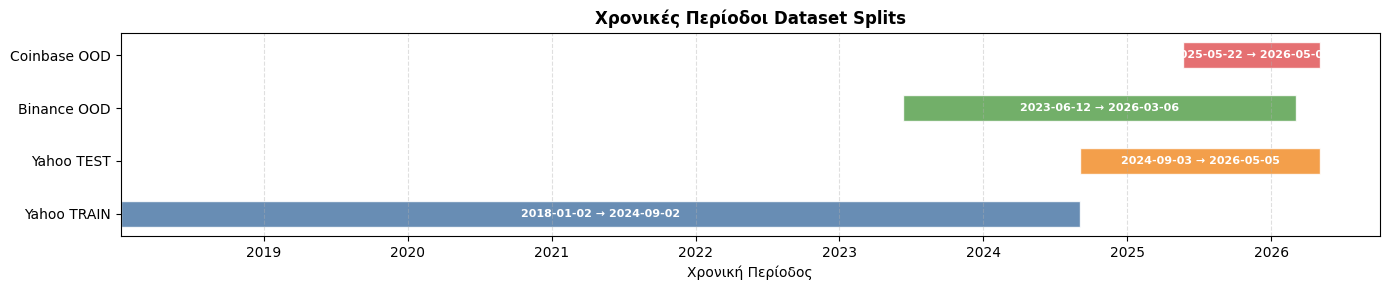


ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ — Yahoo Test Set (BTC-USD)
               RMSE     MAE   QLIKE
GARCH(1,1)   2.1318  1.8211  2.8123
LSTM         1.7934  1.3260  2.9863
GRU          1.7957  1.3328  2.9728
TCN          1.7776  1.1984  3.4326
Transformer  1.7841  1.2808  3.1143
GCN+LSTM     1.7579  1.2695  3.0408
GAT+GRU      1.7528  1.2629  3.0269

Καλύτερο RMSE  → GAT+GRU  (1.7528)
Καλύτερο MAE   → TCN   (1.1984)
Καλύτερο QLIKE → GARCH(1,1) (2.8123)


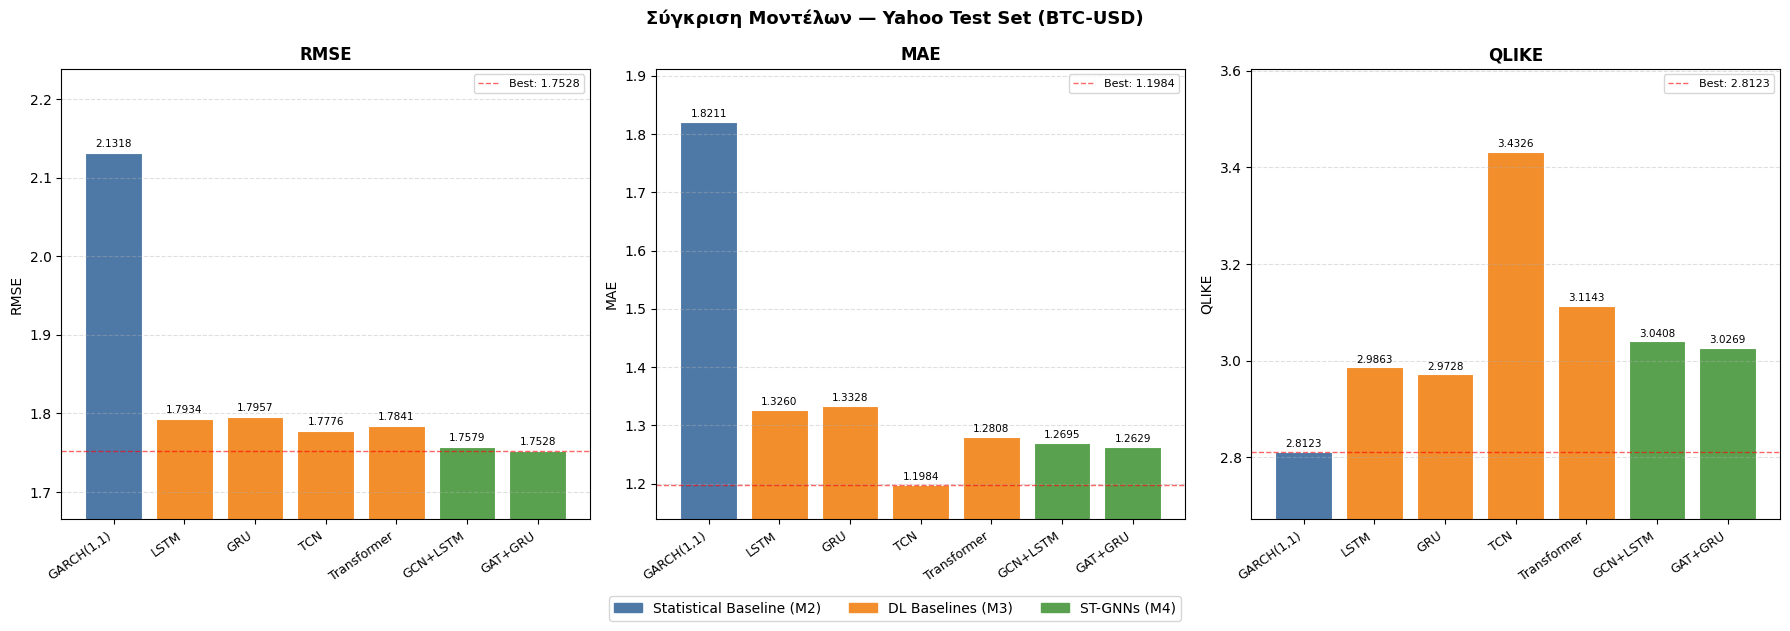

In [16]:
# ==============================================================================
# ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ & ΔΙΑΣΑΦΗΝΙΣΗ ΧΡΟΝΙΚΩΝ ΠΕΡΙΟΔΩΝ (STANDALONE)
# ==============================================================================
import matplotlib.patches as mpatches

# --- 1. TEMPORAL OVERLAP ANALYSIS ---
df_y = pd.read_csv('crypto_log_returns_yahoo.csv',    index_col='Date', parse_dates=True)
df_b = pd.read_csv('crypto_log_returns_binance.csv',  index_col='Date', parse_dates=True)
df_c = pd.read_csv('crypto_log_returns_coinbase.csv', index_col='Date', parse_dates=True)

total_yahoo = len(df_y)
split_idx   = int(total_yahoo * 0.8)

yahoo_train_start = df_y.index[0]
yahoo_train_end   = df_y.index[split_idx - 1]
yahoo_test_start  = df_y.index[split_idx]
yahoo_test_end    = df_y.index[-1]

bin_overlap_train  = df_b[(df_b.index >= yahoo_train_start) & (df_b.index <= yahoo_train_end)]
bin_overlap_test   = df_b[(df_b.index >= yahoo_test_start)  & (df_b.index <= yahoo_test_end)]
coin_overlap_train = df_c[(df_c.index >= yahoo_train_start) & (df_c.index <= yahoo_train_end)]
coin_overlap_test  = df_c[(df_c.index >= yahoo_test_start)  & (df_c.index <= yahoo_test_end)]

print("=" * 65)
print("ΧΡΟΝΙΚΕΣ ΠΕΡΙΟΔΟΙ ΑΝΑ DATASET")
print("=" * 65)
print(f"Yahoo TRAIN : {yahoo_train_start.date()} → {yahoo_train_end.date()} ({split_idx} ημέρες)")
print(f"Yahoo TEST  : {yahoo_test_start.date()} → {yahoo_test_end.date()} ({total_yahoo - split_idx} ημέρες)")
print(f"Binance OOD : {df_b.index[0].date()} → {df_b.index[-1].date()} ({len(df_b)} ημέρες)")
print(f"Coinbase OOD: {df_c.index[0].date()} → {df_c.index[-1].date()} ({len(df_c)} ημέρες)")
print(f"\nBinance  ∩ Yahoo TRAIN : {len(bin_overlap_train)} ημέρες")
print(f"Binance  ∩ Yahoo TEST  : {len(bin_overlap_test)} ημέρες")
print(f"Coinbase ∩ Yahoo TRAIN : {len(coin_overlap_train)} ημέρες")
print(f"Coinbase ∩ Yahoo TEST  : {len(coin_overlap_test)} ημέρες")
print("""
ΣΗΜΕΙΩΣΗ ΜΕΘΟΔΟΛΟΓΙΑΣ:
  Το OOD evaluation είναι SOURCE-LEVEL (διαφορετικό exchange).
  Εκπαίδευση ΜΟΝΟ στα Yahoo δεδομένα — frozen weights στα Binance/Coinbase.
  Η χρονική επικάλυψη αφορά τις ημερομηνίες, ΟΧΙ τα δεδομένα εκπαίδευσης.
""")

# --- 2. TIMELINE VISUALIZATION ---
fig, ax = plt.subplots(figsize=(14, 3))
datasets = {
    'Yahoo TRAIN':  (yahoo_train_start, yahoo_train_end,  '#4e79a7'),
    'Yahoo TEST':   (yahoo_test_start,  yahoo_test_end,   '#f28e2b'),
    'Binance OOD':  (df_b.index[0],     df_b.index[-1],   '#59a14f'),
    'Coinbase OOD': (df_c.index[0],     df_c.index[-1],   '#e15759'),
}
for i, (label, (start, end, color)) in enumerate(datasets.items()):
    ax.barh(i, (end - start).days, left=start, height=0.5,
            color=color, alpha=0.85, edgecolor='white')
    ax.text(start + (end - start)/2, i,
            f'{start.date()} → {end.date()}',
            va='center', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets.keys(), fontsize=10)
ax.set_xlabel('Χρονική Περίοδος')
ax.set_title('Χρονικές Περίοδοι Dataset Splits', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('timeline_splits.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ (HARDCODED - ΠΡΑΓΜΑΤΙΚΑ ΝΟΥΜΕΡΑ) ---
results = {
    'GARCH(1,1)':  {'RMSE': 2.1318, 'MAE': 1.8211, 'QLIKE': 2.8123},
    'LSTM':        {'RMSE': 1.7934, 'MAE': 1.3260, 'QLIKE': 2.9863},
    'GRU':         {'RMSE': 1.7957, 'MAE': 1.3328, 'QLIKE': 2.9728},
    'TCN':         {'RMSE': 1.7776, 'MAE': 1.1984, 'QLIKE': 3.4326},
    'Transformer': {'RMSE': 1.7841, 'MAE': 1.2808, 'QLIKE': 3.1143},
    'GCN+LSTM':    {'RMSE': 1.7579, 'MAE': 1.2695, 'QLIKE': 3.0408},
    'GAT+GRU':     {'RMSE': 1.7528, 'MAE': 1.2629, 'QLIKE': 3.0269},
}
categories = {
    'GARCH(1,1)':  '#4e79a7',
    'LSTM':        '#f28e2b',
    'GRU':         '#f28e2b',
    'TCN':         '#f28e2b',
    'Transformer': '#f28e2b',
    'GCN+LSTM':    '#59a14f',
    'GAT+GRU':     '#59a14f',
}
df_compare = pd.DataFrame(results).T

print("\n" + "=" * 55)
print("ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ — Yahoo Test Set (BTC-USD)")
print("=" * 55)
print(df_compare.round(4).to_string())
print(f"\nΚαλύτερο RMSE  → {df_compare['RMSE'].idxmin()}  ({df_compare['RMSE'].min():.4f})")
print(f"Καλύτερο MAE   → {df_compare['MAE'].idxmin()}   ({df_compare['MAE'].min():.4f})")
print(f"Καλύτερο QLIKE → {df_compare['QLIKE'].idxmin()} ({df_compare['QLIKE'].min():.4f})")

bar_colors = [categories[m] for m in df_compare.index]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Σύγκριση Μοντέλων — Yahoo Test Set (BTC-USD)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['RMSE', 'MAE', 'QLIKE']):
    bars = ax.bar(df_compare.index, df_compare[metric],
                  color=bar_colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, df_compare[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)
    ax.axhline(df_compare[metric].min(), color='red', linestyle='--',
               linewidth=1, alpha=0.6, label=f'Best: {df_compare[metric].min():.4f}')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(df_compare.index, rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(bottom=df_compare[metric].min() * 0.95)

patches = [
    mpatches.Patch(color='#4e79a7', label='Statistical Baseline (M2)'),
    mpatches.Patch(color='#f28e2b', label='DL Baselines (M3)'),
    mpatches.Patch(color='#59a14f', label='ST-GNNs (M4)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)
plt.tight_layout()
plt.savefig('m4_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()